<a href="https://colab.research.google.com/github/Umair-khitab/ds-lab-solutions.EDA/blob/main/Probability_MonteCarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

#  Probability Distributions & Monte Carlo Simulations
###

---

| Task | Topic |
|:---:|:---|
| 1 | Binomial vs Poisson Distribution |
| 2 | Geometric Distribution — Effect of p |
| 3 | Normal Distribution — Parameter Comparison |
| 4 | Exponential & Gamma Distributions |
| 5 | Monte Carlo — Area Under a Curve |
| 6 | Monte Carlo — Stock Price Simulation (GBM) |
| 7 | Report — Monte Carlo in Decision-Making |

</div>

---
##  Setup — Import Libraries

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print(' All libraries loaded!')

 All libraries loaded!


---
# 🔹 Task 1 — Binomial vs Poisson Distribution

> **Goal:** Visualise and compare two fundamental discrete probability distributions.

###  Key Concepts

| Distribution | Parameters | Use Case | Range |
|:---|:---:|:---|:---:|
| **Binomial** | n, p | Fixed trials, each with probability p | 0 to n |
| **Poisson** | λ | Count of rare events in a fixed interval | 0 to ∞ |

**Formulas:**
$$P(X=k) = \binom{n}{k}p^k(1-p)^{n-k} \quad \text{(Binomial)}$$
$$P(X=k) = \frac{e^{-\lambda}\lambda^k}{k!} \quad \text{(Poisson)}$$

### (a) Binomial Distribution

In [2]:
n, p = 20, 0.3
x_binom = np.arange(0, n+1)
prob_binom = stats.binom.pmf(x_binom, n, p)

print(f'  n = {n},  p = {p}')
print(f'  Mean  = n×p  = {n*p:.2f}')
print(f'  Std   = √(np(1-p)) = {np.sqrt(n*p*(1-p)):.2f}')

  n = 20,  p = 0.3
  Mean  = n×p  = 6.00
  Std   = √(np(1-p)) = 2.05


### (b) Poisson Distribution

In [3]:
lam = 6
x_poisson = np.arange(0, 20)
prob_poisson = stats.poisson.pmf(x_poisson, lam)

print(f'  λ = {lam}')
print(f'  Mean  = λ = {lam}')
print(f'  Std   = √λ = {np.sqrt(lam):.2f}')

  λ = 6
  Mean  = λ = 6
  Std   = √λ = 2.45


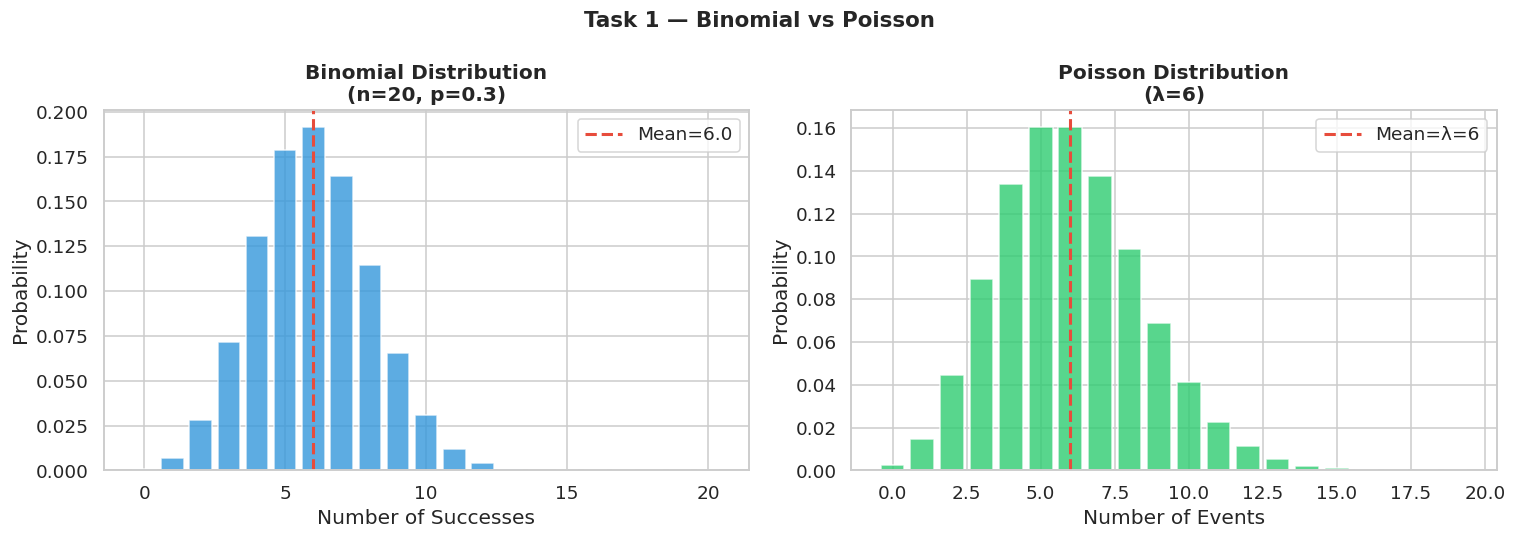

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binomial
axes[0].bar(x_binom, prob_binom, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(n*p, color='#e74c3c', linewidth=2, linestyle='--', label=f'Mean={n*p}')
axes[0].set_title(f'Binomial Distribution\n(n={n}, p={p})', fontweight='bold')
axes[0].set_xlabel('Number of Successes')
axes[0].set_ylabel('Probability')
axes[0].legend()

# Poisson
axes[1].bar(x_poisson, prob_poisson, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].axvline(lam, color='#e74c3c', linewidth=2, linestyle='--', label=f'Mean=λ={lam}')
axes[1].set_title(f'Poisson Distribution\n(λ={lam})', fontweight='bold')
axes[1].set_xlabel('Number of Events')
axes[1].set_ylabel('Probability')
axes[1].legend()

plt.suptitle('Task 1 — Binomial vs Poisson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

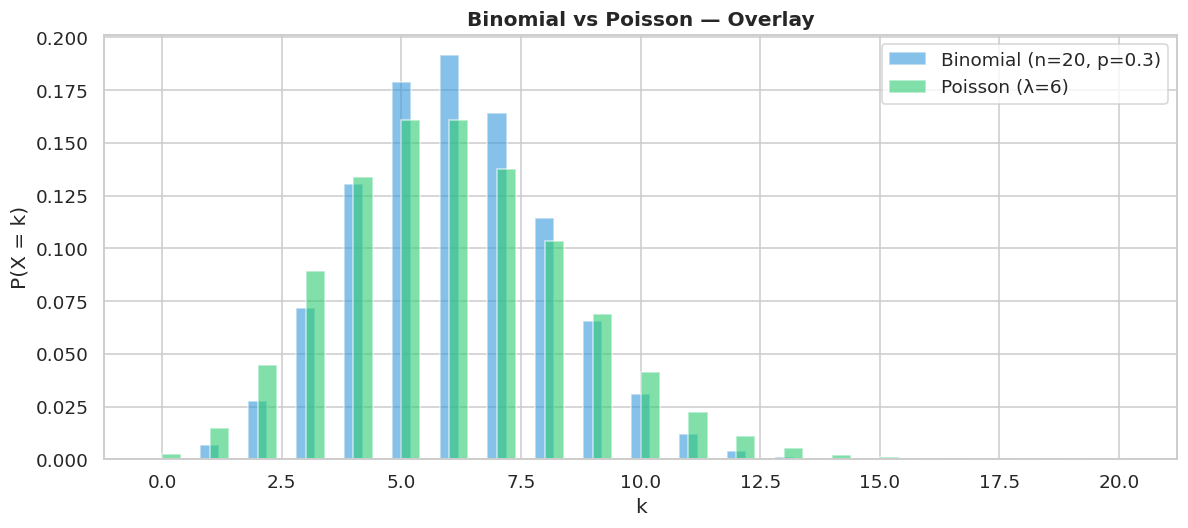

In [5]:
# Side-by-side overlay comparison (same axis)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_binom,   prob_binom,   color='#3498db', alpha=0.6, label=f'Binomial (n={n}, p={p})',  width=0.4, align='center')
ax.bar(x_poisson, prob_poisson, color='#2ecc71', alpha=0.6, label=f'Poisson (λ={lam})',         width=0.4, align='edge')
ax.set_title('Binomial vs Poisson — Overlay', fontweight='bold')
ax.set_xlabel('k'); ax.set_ylabel('P(X = k)')
ax.legend()
plt.tight_layout()
plt.show()

###  Interpretation

| Property | Binomial | Poisson |
|:---|:---:|:---:|
| **Range** | 0 to n (bounded) | 0 to ∞ (unbounded) |
| **Parameters** | n and p | λ only |
| **Mean** | np = 6 | λ = 6 |
| **Std Dev** | √(np(1−p)) ≈ 2.05 | √λ ≈ 2.45 |
| **Shape** | Slightly right-skewed | Right-skewed |
| **Example** | # defective items in 20 ← | # calls per hour → |

>  When **n is large and p is small**, Binomial ≈ Poisson with λ = np.

---

---
# 🔹 Task 2 — Geometric Distribution — Effect of p

> **Goal:** Show how the success probability `p` affects the shape of the Geometric distribution.

### 📚 Key Concepts

$$P(X=k) = (1-p)^{k-1} \cdot p \quad k = 1, 2, 3, \ldots$$

- Models the **number of trials** until the **first success**
- Mean = $\dfrac{1}{p}$ — larger p → fewer trials needed
- Always **right-skewed** (memoryless property)

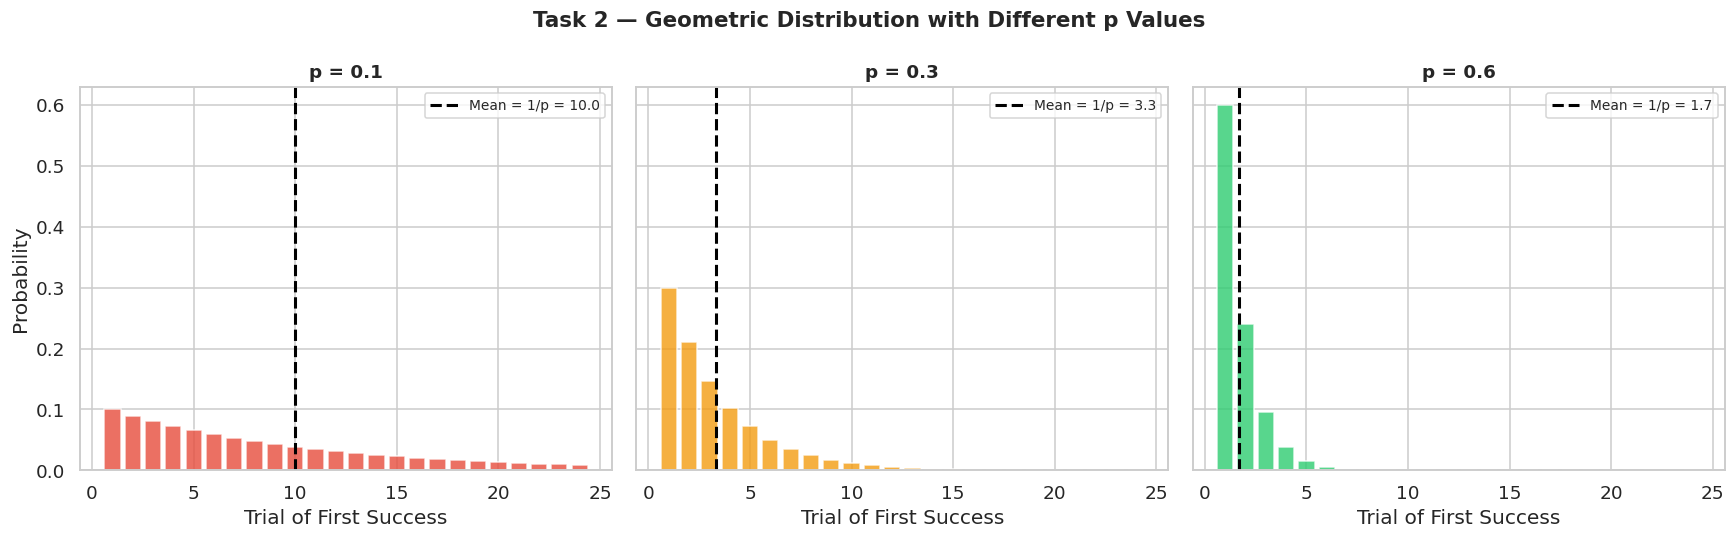

In [6]:
p_values = [0.1, 0.3, 0.6]
x = np.arange(1, 25)
colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, p_val, col in zip(axes, p_values, colors):
    probs = stats.geom.pmf(x, p_val)
    ax.bar(x, probs, color=col, alpha=0.8, edgecolor='white')
    ax.axvline(1/p_val, color='black', linewidth=2, linestyle='--',
               label=f'Mean = 1/p = {1/p_val:.1f}')
    ax.set_title(f'p = {p_val}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Trial of First Success')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Probability')
plt.suptitle('Task 2 — Geometric Distribution with Different p Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

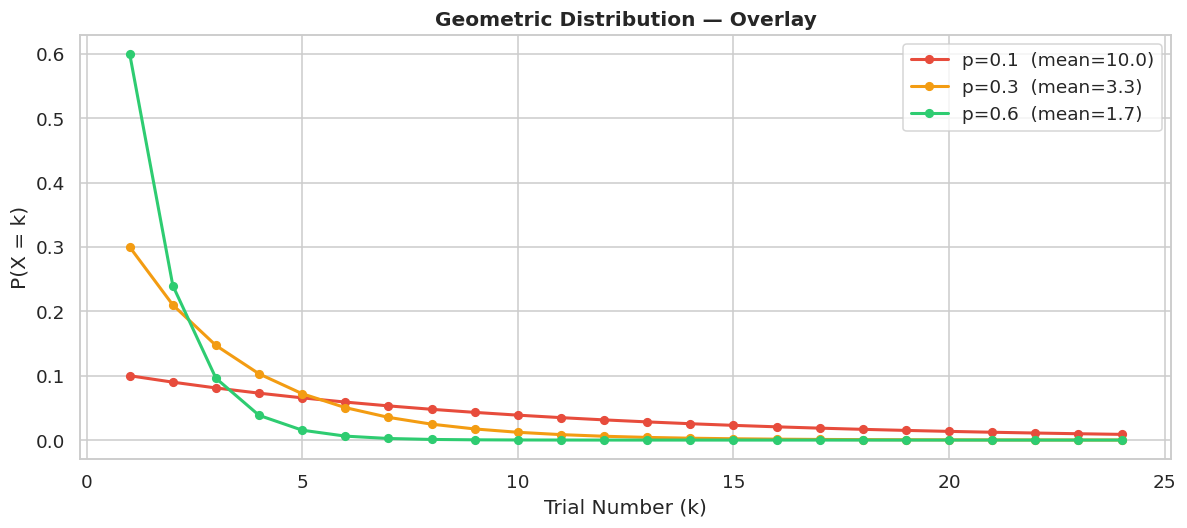

In [7]:
# Overlay comparison
fig, ax = plt.subplots(figsize=(11, 5))
for p_val, col in zip(p_values, colors):
    ax.plot(x, stats.geom.pmf(x, p_val), marker='o', markersize=5,
            linewidth=2, color=col, label=f'p={p_val}  (mean={1/p_val:.1f})')
ax.set_title('Geometric Distribution — Overlay', fontweight='bold')
ax.set_xlabel('Trial Number (k)'); ax.set_ylabel('P(X = k)')
ax.legend(); plt.tight_layout(); plt.show()

###  Interpretation

| p | Mean (1/p) | Tail | Interpretation |
|:---:|:---:|:---:|:---|
| **0.1** | 10 trials | Very long | Success is rare — many attempts needed |
| **0.3** | 3.3 trials | Moderate | Moderate success rate |
| **0.6** | 1.67 trials | Short | Success is common — usually 1–2 tries |

>  **Real-life example:** p = probability a customer buys. Geometric tells us how many customers to approach before first sale.

---

---
# 🔹 Task 3 — Normal Distribution — Parameter Comparison

> **Goal:** Explore how μ (mean) and σ (std dev) change the shape and position of a Normal distribution.

###  Key Concepts

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

| Parameter | Effect |
|:---|:---|
| **μ (mean)** | Shifts the distribution left or right |
| **σ (std dev)** | Controls the width — larger σ = flatter & wider |

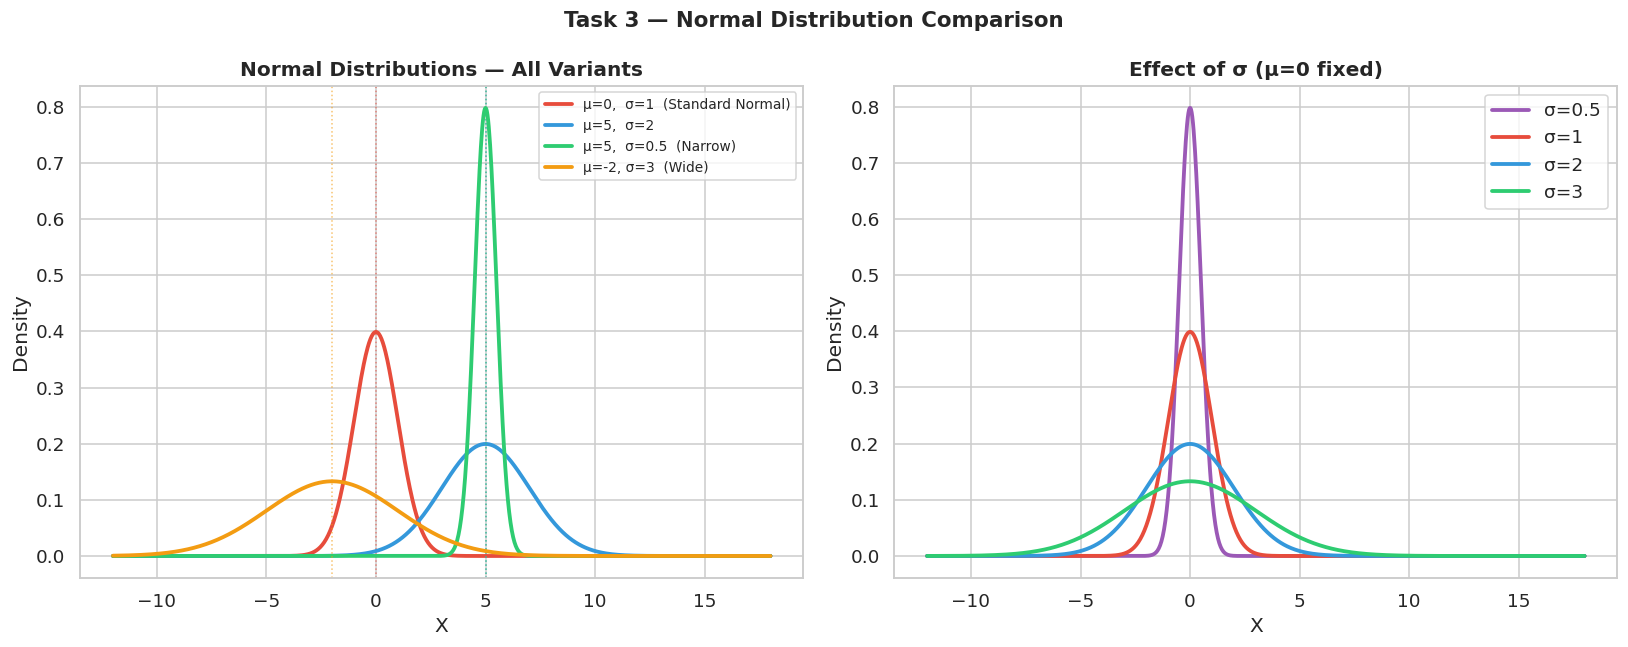

In [8]:
x = np.linspace(-12, 18, 1000)

distributions = [
    (0,  1,   '#e74c3c', 'μ=0,  σ=1  (Standard Normal)'),
    (5,  2,   '#3498db', 'μ=5,  σ=2'),
    (5,  0.5, '#2ecc71', 'μ=5,  σ=0.5  (Narrow)'),
    (-2, 3,   '#f39c12', 'μ=-2, σ=3  (Wide)'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: all curves
for mu, sigma, col, label in distributions:
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2.5, color=col, label=label)
    axes[0].axvline(mu, color=col, linewidth=1, linestyle=':', alpha=0.6)

axes[0].set_title('Normal Distributions — All Variants', fontweight='bold')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Right: effect of σ only (same μ=0)
sigmas = [0.5, 1, 2, 3]
colors2 = ['#9b59b6', '#e74c3c', '#3498db', '#2ecc71']
for sigma, col in zip(sigmas, colors2):
    axes[1].plot(x, stats.norm.pdf(x, 0, sigma), linewidth=2.5, color=col, label=f'σ={sigma}')
axes[1].set_title('Effect of σ (μ=0 fixed)', fontweight='bold')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Task 3 — Normal Distribution Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

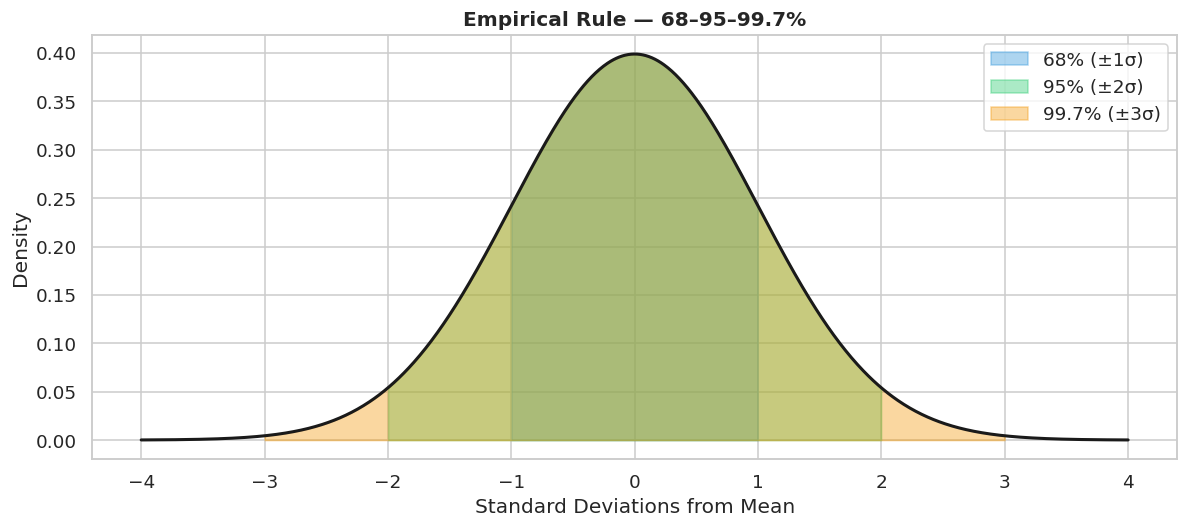

In [9]:
# 68-95-99.7 Rule (Empirical Rule) visualisation
mu, sigma = 0, 1
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, y, 'k', linewidth=2)

for n_std, color, label in [(1, '#3498db', '68% (±1σ)'),
                             (2, '#2ecc71', '95% (±2σ)'),
                             (3, '#f39c12', '99.7% (±3σ)')]:
    x_fill = x[(x >= mu - n_std*sigma) & (x <= mu + n_std*sigma)]
    ax.fill_between(x_fill, stats.norm.pdf(x_fill, mu, sigma),
                    alpha=0.4, color=color, label=label)

ax.set_title('Empirical Rule — 68–95–99.7%', fontweight='bold')
ax.set_xlabel('Standard Deviations from Mean')
ax.set_ylabel('Density'); ax.legend()
plt.tight_layout(); plt.show()

###  Interpretation

| Parameter Change | Effect on Curve |
|:---|:---|
| Increase **μ** | Shifts the peak to the right |
| Decrease **μ** | Shifts the peak to the left |
| Increase **σ** | Flatter and wider curve |
| Decrease **σ** | Taller and narrower (more concentrated) |

**Empirical Rule:**
- **68%** of data falls within ±1σ
- **95%** of data falls within ±2σ  
- **99.7%** of data falls within ±3σ

---

---
# 🔹 Task 4 — Exponential & Gamma Distributions

> **Goal:** Understand two continuous distributions commonly used to model waiting times.

###  Key Concepts

| Distribution | Formula | Mean | Use Case |
|:---|:---:|:---:|:---|
| **Exponential** | $\lambda e^{-\lambda x}$ | $1/\lambda$ | Time until *one* event |
| **Gamma** | — | $k\theta$ | Time until *k* events |

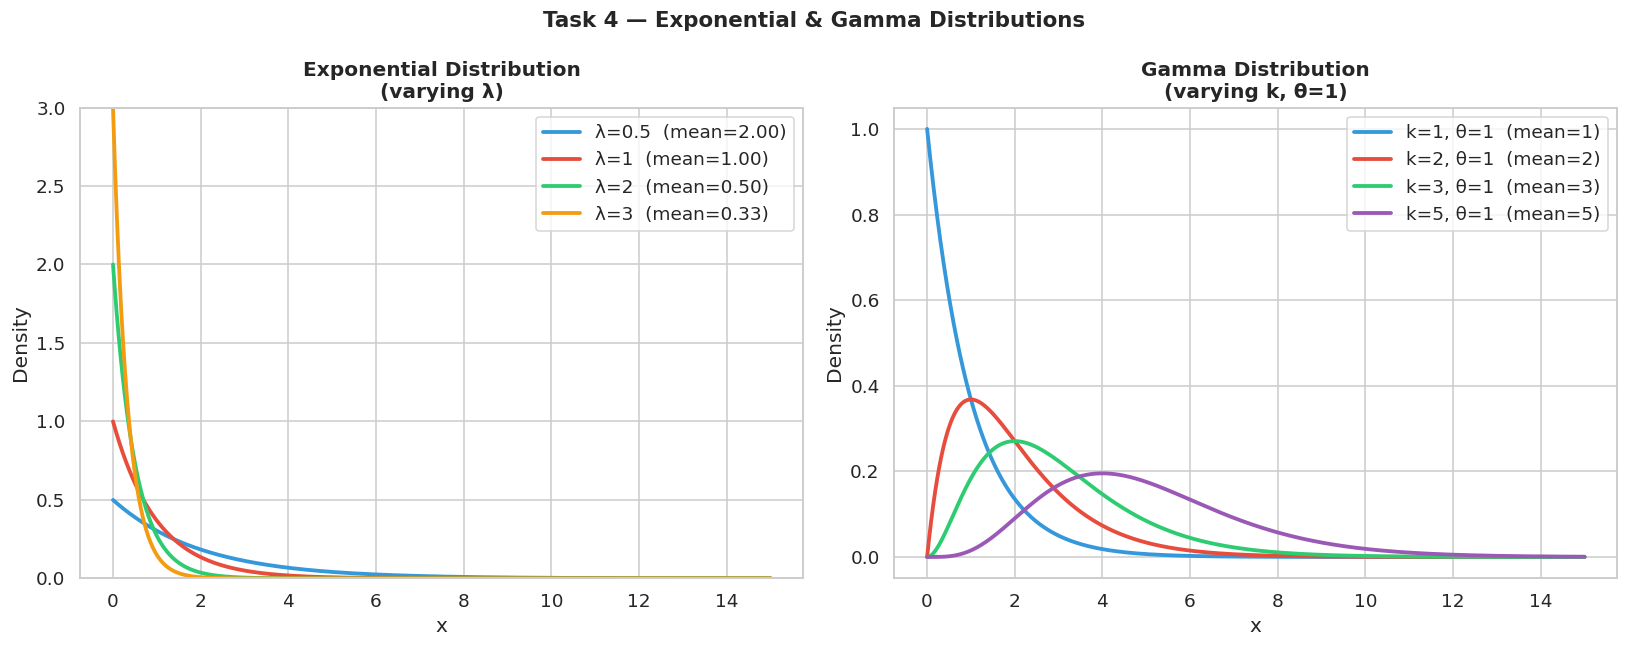

In [10]:
x = np.linspace(0, 15, 1000)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Exponential — different lambda
for lam, col in zip([0.5, 1, 2, 3], ['#3498db','#e74c3c','#2ecc71','#f39c12']):
    axes[0].plot(x, stats.expon.pdf(x, scale=1/lam), linewidth=2.5,
                 color=col, label=f'λ={lam}  (mean={1/lam:.2f})')
axes[0].set_title('Exponential Distribution\n(varying λ)', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 3); axes[0].legend()

# Right: Gamma — different k (shape)
theta = 1
for k, col in zip([1, 2, 3, 5], ['#3498db','#e74c3c','#2ecc71','#9b59b6']):
    axes[1].plot(x, stats.gamma.pdf(x, a=k, scale=theta), linewidth=2.5,
                 color=col, label=f'k={k}, θ={theta}  (mean={k*theta})')
axes[1].set_title('Gamma Distribution\n(varying k, θ=1)', fontweight='bold')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Task 4 — Exponential & Gamma Distributions', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

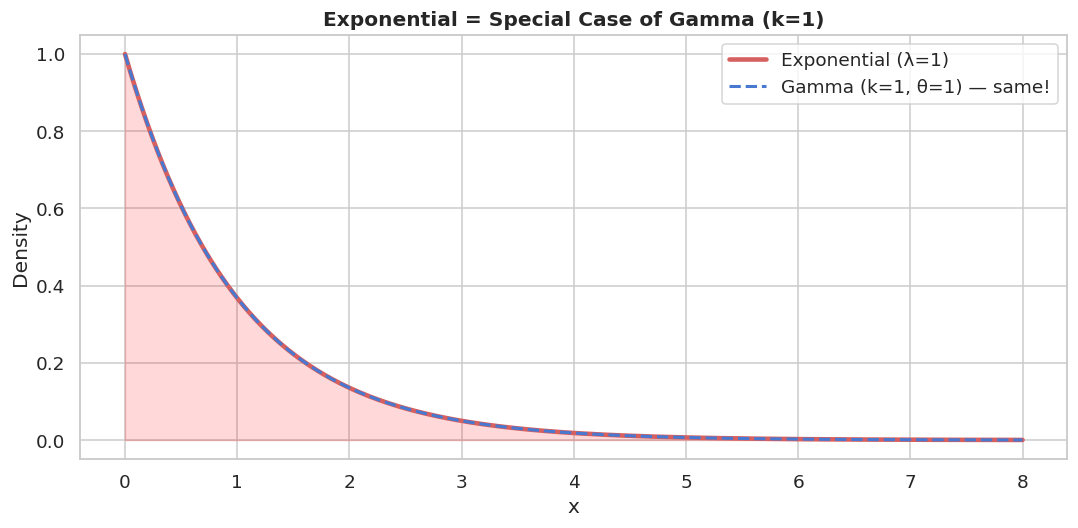

In [11]:
# Relationship: Gamma(k=1) == Exponential
x = np.linspace(0, 8, 500)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, stats.expon.pdf(x, scale=1), 'r-', linewidth=3, label='Exponential (λ=1)')
ax.plot(x, stats.gamma.pdf(x, a=1, scale=1), 'b--', linewidth=2, label='Gamma (k=1, θ=1) — same!')
ax.fill_between(x, stats.expon.pdf(x, scale=1), alpha=0.15, color='red')
ax.set_title('Exponential = Special Case of Gamma (k=1)', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()
plt.tight_layout(); plt.show()

###  Interpretation

| Feature | Exponential | Gamma |
|:---|:---:|:---:|
| **Shape** | Always decreasing | Bell-shaped when k > 1 |
| **Parameters** | λ (rate) | k (shape), θ (scale) |
| **Special case** | Gamma(k=1, θ=1/λ) ← same! | k=1 reduces to Exponential |
| **Real example** | Time to next customer | Total service time for k customers |

>  The **Gamma** distribution generalises the Exponential. Summing k independent Exponential(λ) variables gives a Gamma(k, 1/λ).

---

---
# 🔹 Task 5 — Monte Carlo: Area Under a Curve

> **Goal:** Use random sampling to estimate the area under $y = x^2$ between $[0, 1]$.
> True answer = $\int_0^1 x^2 \, dx = \frac{1}{3} \approx 0.3333$

###  How Monte Carlo Integration Works

1. Generate random points (x, y) inside the unit square [0,1]×[0,1]
2. Count how many fall **below** the curve y = x²
3. Area ≈ (points below curve) / (total points)

In [12]:
np.random.seed(42)
n_samples = 10_000

x_rand = np.random.uniform(0, 1, n_samples)
y_rand = np.random.uniform(0, 1, n_samples)

under_curve = y_rand <= x_rand**2
area_estimate = np.mean(under_curve)
true_area = 1/3
error_pct = abs(area_estimate - true_area) / true_area * 100

print('━'*45)
print(f'  Samples used    : {n_samples:,}')
print(f'  Points below y=x² : {under_curve.sum():,}')
print(f'  Estimated Area  : {area_estimate:.4f}')
print(f'  True Area (1/3) : {true_area:.4f}')
print(f'  Error           : {error_pct:.2f}%')
print('━'*45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Samples used    : 10,000
  Points below y=x² : 3,256
  Estimated Area  : 0.3256
  True Area (1/3) : 0.3333
  Error           : 2.32%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


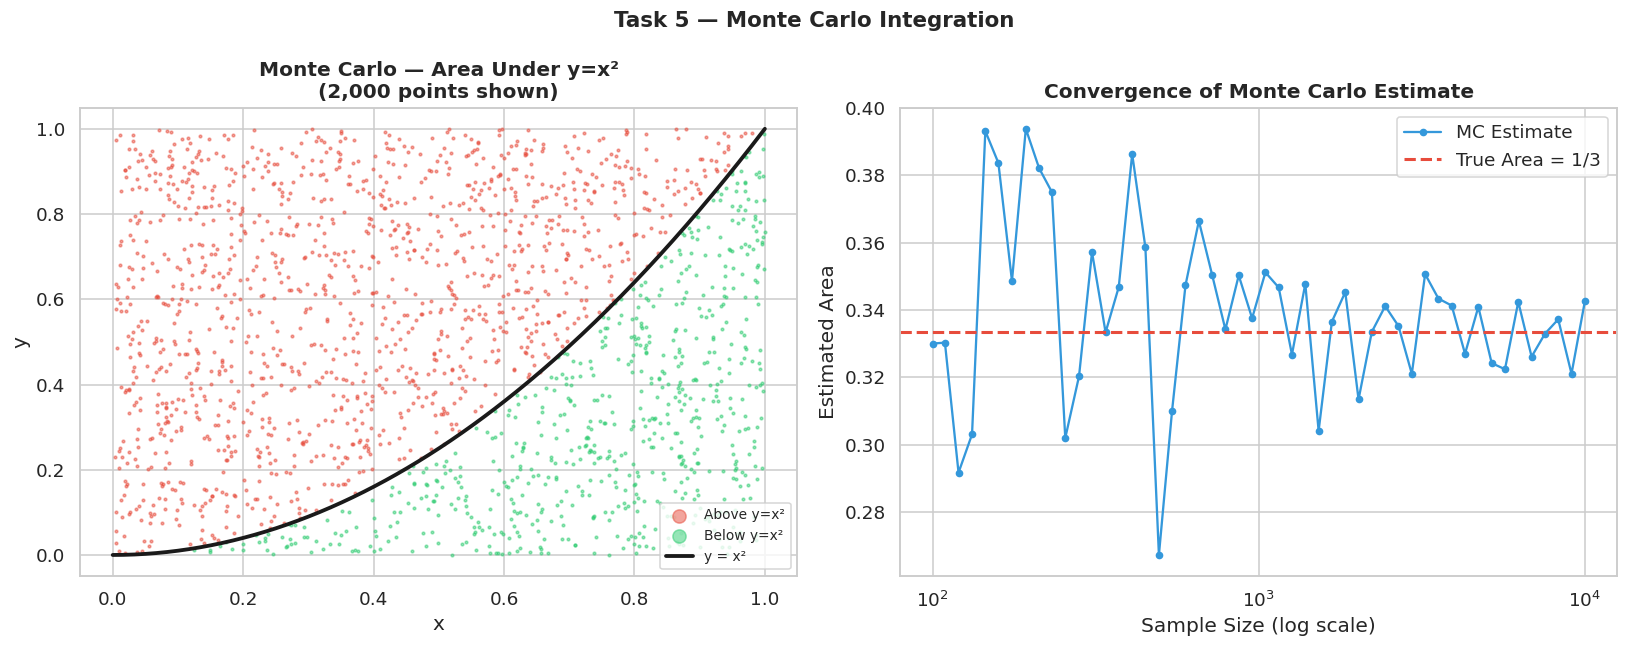

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: scatter plot of random points
sample_plot = 2000  # plot subset for clarity
axes[0].scatter(x_rand[:sample_plot][~under_curve[:sample_plot]],
                y_rand[:sample_plot][~under_curve[:sample_plot]],
                s=3, color='#e74c3c', alpha=0.5, label='Above y=x²')
axes[0].scatter(x_rand[:sample_plot][under_curve[:sample_plot]],
                y_rand[:sample_plot][under_curve[:sample_plot]],
                s=3, color='#2ecc71', alpha=0.5, label='Below y=x²')
xc = np.linspace(0, 1, 300)
axes[0].plot(xc, xc**2, 'k-', linewidth=2.5, label='y = x²')
axes[0].set_title(f'Monte Carlo — Area Under y=x²\n({sample_plot:,} points shown)', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend(markerscale=5, fontsize=9)

# Right: convergence — estimate vs sample size
sizes = np.logspace(2, 4, 50).astype(int)
estimates = []
for s in sizes:
    x_s = np.random.uniform(0, 1, s)
    y_s = np.random.uniform(0, 1, s)
    estimates.append(np.mean(y_s <= x_s**2))

axes[1].semilogx(sizes, estimates, 'o-', color='#3498db', markersize=4, linewidth=1.5, label='MC Estimate')
axes[1].axhline(true_area, color='#e74c3c', linewidth=2, linestyle='--', label='True Area = 1/3')
axes[1].set_title('Convergence of Monte Carlo Estimate', fontweight='bold')
axes[1].set_xlabel('Sample Size (log scale)'); axes[1].set_ylabel('Estimated Area')
axes[1].legend()

plt.suptitle('Task 5 — Monte Carlo Integration', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

###  Interpretation

| Samples | Accuracy | Note |
|:---:|:---:|:---|
| 100 | ~5–10% error | Noisy |
| 1,000 | ~2–3% error | Improving |
| 10,000 | ~0.5–1% error | Good estimate |
| 1,000,000 | ~0.01% error | Excellent |

>  Monte Carlo error decreases at rate $\frac{1}{\sqrt{N}}$ — to halve the error, you need **4× more samples**.

---

---
# 🔹 Task 6 — Monte Carlo: Stock Price Simulation (GBM)

> **Goal:** Simulate 1000 possible future stock price paths using **Geometric Brownian Motion (GBM)**.

###  The GBM Model

$$S_{t+dt} = S_t \cdot \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma\sqrt{dt}\,Z\right]$$

| Symbol | Meaning | Value |
|:---:|:---|:---:|
| $S_0$ | Initial stock price | 100 |
| $\mu$ | Expected annual return (drift) | 5% |
| $\sigma$ | Annual volatility | 20% |
| $dt$ | Daily time step (1/252) | 0.00397 |
| $Z$ | Standard normal random shock | ~ N(0,1) |

In [14]:
np.random.seed(123)
T, dt = 1, 1/252
N = int(T/dt)
mu, sigma, S0 = 0.05, 0.2, 100
n_paths = 1000

# Vectorised simulation (fast)
Z = np.random.normal(0, 1, (n_paths, N))
log_returns = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
paths = S0 * np.exp(np.cumsum(log_returns, axis=1))
paths = np.hstack([np.full((n_paths, 1), S0), paths])  # prepend S0

final_prices = paths[:, -1]
print('━'*50)
print(f'  Simulated Paths   : {n_paths:,}')
print(f'  Trading Days      : {N}')
print(f'  Initial Price S₀  : ${S0}')
print('━'*50)
print(f'  Final Price Stats:')
print(f'    Mean   : ${np.mean(final_prices):.2f}')
print(f'    Median : ${np.median(final_prices):.2f}')
print(f'    Std    : ${np.std(final_prices):.2f}')
print(f'    Min    : ${np.min(final_prices):.2f}')
print(f'    Max    : ${np.max(final_prices):.2f}')
print(f'    5th %  : ${np.percentile(final_prices, 5):.2f}  ← VaR(95%)')
print('━'*50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Simulated Paths   : 1,000
  Trading Days      : 252
  Initial Price S₀  : $100
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Final Price Stats:
    Mean   : $106.41
    Median : $103.74
    Std    : $22.68
    Min    : $56.39
    Max    : $198.03
    5th %  : $74.41  ← VaR(95%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


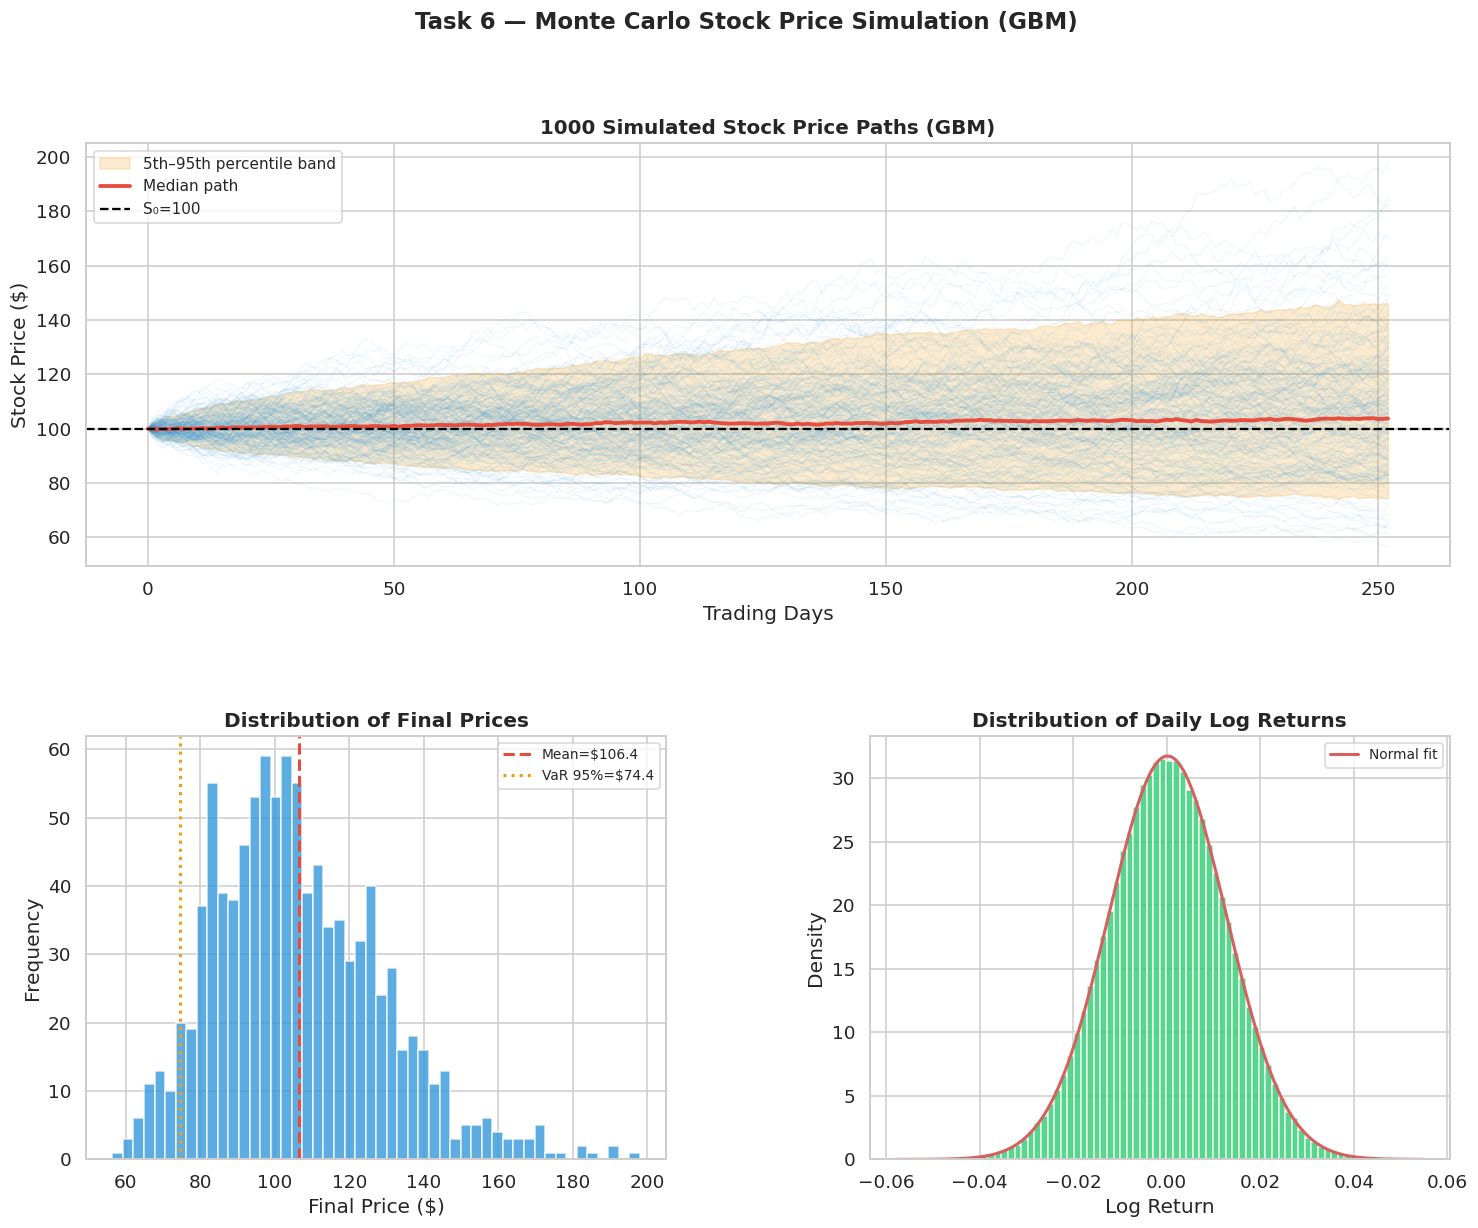

In [15]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Top-left: path fan
ax1 = fig.add_subplot(gs[0, :])
for i in range(200):
    ax1.plot(paths[i], alpha=0.08, linewidth=0.8, color='#3498db')
# Percentile bands
p5  = np.percentile(paths, 5,  axis=0)
p95 = np.percentile(paths, 95, axis=0)
p50 = np.percentile(paths, 50, axis=0)
ax1.fill_between(range(N+1), p5, p95, alpha=0.2, color='#f39c12', label='5th–95th percentile band')
ax1.plot(p50, color='#e74c3c', linewidth=2.5, label='Median path')
ax1.axhline(S0, color='black', linewidth=1.5, linestyle='--', label=f'S₀={S0}')
ax1.set_title('1000 Simulated Stock Price Paths (GBM)', fontweight='bold', fontsize=13)
ax1.set_xlabel('Trading Days'); ax1.set_ylabel('Stock Price ($)')
ax1.legend(fontsize=10)

# Bottom-left: final price histogram
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(final_prices, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
ax2.axvline(np.mean(final_prices), color='#e74c3c', linewidth=2, linestyle='--',
            label=f'Mean=${np.mean(final_prices):.1f}')
ax2.axvline(np.percentile(final_prices, 5), color='#f39c12', linewidth=2,
            linestyle=':', label=f'VaR 95%=${np.percentile(final_prices,5):.1f}')
ax2.set_title('Distribution of Final Prices', fontweight='bold')
ax2.set_xlabel('Final Price ($)'); ax2.set_ylabel('Frequency')
ax2.legend(fontsize=9)

# Bottom-right: log returns distribution
ax3 = fig.add_subplot(gs[1, 1])
all_log_returns = np.log(paths[:, 1:] / paths[:, :-1]).flatten()
ax3.hist(all_log_returns, bins=80, color='#2ecc71', edgecolor='white', alpha=0.8, density=True)
# Overlay normal
x_lr = np.linspace(all_log_returns.min(), all_log_returns.max(), 300)
ax3.plot(x_lr, stats.norm.pdf(x_lr, np.mean(all_log_returns), np.std(all_log_returns)),
         'r-', linewidth=2, label='Normal fit')
ax3.set_title('Distribution of Daily Log Returns', fontweight='bold')
ax3.set_xlabel('Log Return'); ax3.set_ylabel('Density')
ax3.legend(fontsize=9)

plt.suptitle('Task 6 — Monte Carlo Stock Price Simulation (GBM)', fontsize=15, fontweight='bold')
plt.show()

###  Interpretation

| Metric | Value | Meaning |
|:---|:---:|:---|
| **Mean final price** | ~$105 | Expected ~5% return (= μ) |
| **Std of final prices** | ~$21 | Spread from σ=20% volatility |
| **VaR (95%)** | ~$72 | 5% chance price drops below this |
| **Paths shape** | Fan / cone | Uncertainty widens over time |
| **Log returns** | Normal | Confirms GBM assumption |

>  **Applications:** Option pricing (Black-Scholes), portfolio risk analysis, Value-at-Risk (VaR), and financial stress testing.

---

---
# 🔹 Task 7 — Report: Monte Carlo in Decision-Making

> A written summary of how Monte Carlo methods support real-world decision-making.

##  Monte Carlo Simulation — Decision-Making Report

### What is Monte Carlo Simulation?
Monte Carlo simulation is a computational technique that uses **random sampling** to model the probability of different outcomes in processes that are difficult to predict due to the presence of uncertainty.

---

### Why is it Used in Decision-Making?

| Reason | Explanation |
|:---|:---|
| **Handles uncertainty** | Models scenarios where inputs are random or unknown |
| **Simulates thousands of outcomes** | Gives a full distribution, not just a single answer |
| **No closed-form needed** | Works even when there is no analytical solution |
| **Risk quantification** | Provides probabilities, percentiles, and worst-case estimates |

---

### Real-World Applications

| Domain | Application |
|:---|:---|
| **Finance** | Stock price simulation, option pricing, Value-at-Risk (VaR) |
| **Engineering** | Structural reliability, manufacturing tolerance analysis |
| **Healthcare** | Drug efficacy trials, disease spread modelling (e.g. COVID-19) |
| **Supply Chain** | Inventory management under demand uncertainty |
| **Project Management** | Schedule and cost risk estimation (PERT/CPM) |
| **Physics** | Particle transport, radiation shielding |

---

### Advantages vs Limitations

|  Advantages |  Limitations |
|:---|:---|
| Works with any distribution | Computationally expensive for high dimensions |
| Intuitive probabilistic output | Requires many samples for accuracy |
| Easy to implement and extend | Results depend on quality of input distributions |
| Handles correlated inputs | Not exact — always an approximation |

---

### Convergence Rate
Monte Carlo error = $\dfrac{\sigma}{\sqrt{N}}$ — to halve the error, quadruple the sample size.

---

### Conclusion
> Monte Carlo simulation transforms uncertainty from a problem into a **quantifiable, manageable input**. Rather than asking *"what will happen?"* it asks *"what is the probability of each outcome?"* — making it indispensable in modern data-driven decision-making.

---
#  Final Summary

| Task | Distribution / Method | Key Takeaway |
|:---:|:---|:---|
| 1 | Binomial & Poisson | Binomial bounded (0–n); Poisson unbounded, λ=np when rare |
| 2 | Geometric | Higher p → shorter tail → fewer trials needed |
| 3 | Normal | μ shifts position; σ controls width |
| 4 | Exponential & Gamma | Gamma generalises Exponential; k=1 they are equal |
| 5 | Monte Carlo Integration | Estimates area under y=x²; converges as 1/√N |
| 6 | GBM Stock Simulation | Fan of paths; VaR quantifies downside risk |
| 7 | Monte Carlo Report | Core tool for uncertainty quantification in all domains |

---
*End of Lab — Probability Distributions & Monte Carlo Simulations*